In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
# https://huggingface.co/datasets/agentlans/ai-product-reviews

/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load datase
ds = load_dataset("naga-jay/amazon-laptop-gpu-reviews")

Generating train split: 100%|██████████| 32759/32759 [00:00<00:00, 266710.42 examples/s]


In [3]:
ds.column_names

{'train': ['rating',
  'title',
  'text',
  'images',
  'asin',
  'parent_asin',
  'user_id',
  'timestamp',
  'helpful_vote',
  'verified_purchase']}

Class distribution:
 rating
1.0     5678
2.0     2125
3.0     2530
4.0     5109
5.0    17317
Name: count, dtype: int64


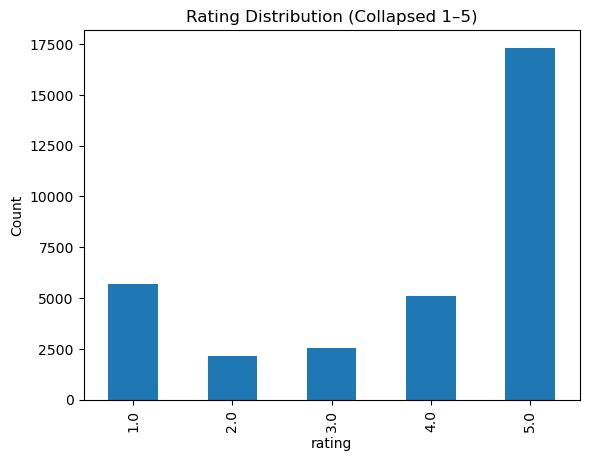


Balanced class distribution:
 rating
1.0    2125
2.0    2125
3.0    2125
4.0    2125
5.0    2125
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_61408/2287509.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("rating", group_keys=False).apply(


In [4]:
# ds = load_dataset("Mouwiya/drug-reviews")

# Convert to Pandas for exploration (train split only as example)
df = ds["train"].to_pandas()


# Check distribution (imbalance)
rating_counts = df["rating"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("rating")
plt.ylabel("Count")
plt.show()

# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("rating", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["rating"].value_counts())

In [6]:
# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("rating", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["rating"].value_counts())


Balanced class distribution:
 rating
1.0    2125
2.0    2125
3.0    2125
4.0    2125
5.0    2125
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_61408/3076841033.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("rating", group_keys=False).apply(


# This seems to be a good dataset!! 

In [7]:
# save the balanced dataset to you current directory
df.to_csv("amazonlaptop_review.csv")

In [8]:
#from transformers import pipeline

#classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

#text = "This drug really helped with my pain but caused nausea."
#candidate_labels = ["very negative", "negative", "neutral", "positive", "very positive"]

#result = classifier(text, candidate_labels)
#print(result)